# 03b — ARIMA / ARIMAX Baseline (Daily, 1-step-ahead)

Same model family as `03_arima_baseline.ipynb` but operating on **daily** log-returns
with **1-trading-day-ahead** forecasts. Kept alongside the weekly notebook so both
horizons can be compared in `07_evaluation.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120


## 1. Load features

In [2]:
train = pd.read_csv('../data/processed/train.csv', index_col=0, parse_dates=True)
test  = pd.read_csv('../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return']

y_train = train[TARGET].dropna()
y_test  = test[TARGET].dropna()
print(f'Daily train: {len(y_train)} obs  |  test: {len(y_test)} obs')


Daily train: 1755 obs  |  test: 500 obs


## 2. Order selection via AIC grid search (daily)

In [3]:
best_aic, best_order = np.inf, (1, 0, 1)
results = []

for p in range(0, 5):
    for q in range(0, 5):
        try:
            m = ARIMA(y_train, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': m.aic, 'bic': m.bic})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('aic').head(10)
print(f'Best ARIMA order (daily): {best_order}  AIC: {best_aic:.2f}')
results_df


Best ARIMA order (daily): (1, 0, 4)  AIC: -9192.40


,p,q,aic,bic
9,1,4,-9192.404128,-9154.112559
4,0,4,-9191.910822,-9159.089478
20,4,0,-9191.661976,-9158.840631
2,0,2,-9191.468215,-9169.587318
13,2,3,-9191.467247,-9153.175678
10,2,0,-9190.323787,-9168.442890
8,1,3,-9189.973945,-9157.152600
12,2,2,-9189.914401,-9157.093056
21,4,1,-9189.798121,-9151.506552
14,2,4,-9189.655209,-9145.893416


## 3. Forecast schemes — motivation

Two approaches for generating 1-step-ahead out-of-sample forecasts:

**Recursive (expanding window)**
At each step $t$, refit ARIMA on *all* data from the start of the sample up to $t-1$.
The window grows by one observation each day. Theoretically optimal if the
data-generating process is stationary — more data is always better.

**Rolling (fixed window)**
At each step $t$, refit ARIMA on only the most recent $W$ observations.
The oldest observation is dropped as a new one arrives, keeping the window fixed.
More robust to structural breaks and regime changes — relevant for silver given the
qualitative shift in market dynamics around the 2020–2021 retail squeeze.

---

### Ad-hoc order comparison (motivated by EDA)

The ACF showed a small but consistent spike at lag 2, suggesting a possible MA(2)
component. Before running the slow rolling forecasts below, we do a quick static
comparison — fit once on train, predict on test — to see whether the lag-2 structure
translates into better out-of-sample performance.

Orders tested:
- `(0,0,0)` — white noise / constant mean (strictest baseline)
- `(0,0,2)` — MA(2) suggested by the ACF lag-2 spike
- `(2,0,0)` — AR(2) symmetric alternative
- AIC-best  — whatever the grid search selected above


In [40]:
# Static comparison on daily data
from statsmodels.tsa.arima.model import ARIMA as _ARIMA

candidate_orders = {
    'ARIMA(0,0,0)': (0, 0, 0),
    'ARIMA(0,0,2)': (0, 0, 2),
    'ARIMA(2,0,0)': (2, 0, 0),
    f'ARIMA{best_order} (AIC-best)': best_order,
}

print(f'{"Model":<32}  {"AIC":>10}  {"BIC":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 70)

for name, order in candidate_orders.items():
    try:
        m    = _ARIMA(y_train, order=order).fit()
        fc   = m.forecast(steps=len(y_test))
        pred = np.asarray(fc)
        mask = ~np.isnan(pred) & ~np.isnan(y_test.values)
        act_ = y_test.values[mask]; prd_ = pred[mask]
        da_  = np.mean(np.sign(act_) == np.sign(prd_))
        wda_ = (np.sum(np.abs(act_) * (np.sign(act_) == np.sign(prd_)))
                / np.sum(np.abs(act_)))
        print(f'{name:<32}  {m.aic:>10.2f}  {m.bic:>10.2f}  {da_:>6.3f}  {wda_:>6.3f}')
    except Exception as e:
        print(f'{name:<32}  ERROR: {e}')


Model                                    AIC         BIC      DA     WDA
----------------------------------------------------------------------
ARIMA(0,0,0)                        -1361.66    -1353.86   0.486   0.527
ARIMA(0,0,2)                        -1357.70    -1342.10   0.486   0.527
ARIMA(2,0,0)                        -1357.69    -1342.09   0.486   0.527
ARIMA(0, 0, 0) (AIC-best)           -1361.66    -1353.86   0.486   0.527


## 3. Forecast functions

In [4]:
def recursive_forecast(y_train, y_test, order, exog_train=None, exog_test=None):
    """Expanding-window 1-step-ahead forecast."""
    history = list(y_train)
    preds   = []
    exog_h  = list(exog_train.values) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
    return np.array(preds)


def rolling_forecast(y_train, y_test, order, window_size=500,
                     exog_train=None, exog_test=None):
    """Fixed-window 1-step-ahead forecast (window_size in trading days)."""
    history = list(y_train[-window_size:])
    preds   = []
    exog_h  = list(exog_train.values[-window_size:]) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        history.pop(0)
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
            exog_h.pop(0)
    return np.array(preds)


## 4. ARIMA forecasts

In [5]:
print('Running ARIMA recursive...')
preds_arima_rec = recursive_forecast(y_train, y_test, best_order)
print('Running ARIMA rolling (window=500 days)...')
preds_arima_rol = rolling_forecast(y_train, y_test, best_order, window_size=500)
print('Done')


Running ARIMA recursive...
Running ARIMA rolling (window=500 days)...
Done


## 5. ARIMAX — lagged market exog

All exogenous variables are **lagged by 1 day**: use yesterday's gold/USD/copper/S&P500
to predict today's silver return. Same-day exog would be a look-ahead leak since all
these are closing prices.


In [6]:
exog_cols = [c for c in EXOG if c in train.columns]

# Lag exog by 1 day — shift train, prepend last training row to test
X_train_lag = train[exog_cols].shift(1).reindex(y_train.index).fillna(0)
X_test_lag  = pd.concat([
    train[exog_cols].iloc[[-1]],
    test[exog_cols].iloc[:-1].reindex(y_test.index[1:])
]).fillna(0)
X_test_lag.index = y_test.index

print('Running ARIMAX recursive (lagged)...')
preds_arimax_rec = recursive_forecast(y_train, y_test, best_order,
                                      exog_train=X_train_lag, exog_test=X_test_lag)
print('Running ARIMAX rolling (lagged, window=500)...')
preds_arimax_rol = rolling_forecast(y_train, y_test, best_order, window_size=500,
                                    exog_train=X_train_lag, exog_test=X_test_lag)
print('Done')


Running ARIMAX recursive (lagged)...
Running ARIMAX rolling (lagged, window=500)...
Done


## 6. Evaluation

In [10]:
actuals = y_test.values

def evaluate(name, y_true, y_pred):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    if mask.sum() == 0:
        print(f'{name:45s}  No valid predictions')
        return None
    y_t = y_true[mask]; y_p = y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    da   = np.mean(np.sign(y_t) == np.sign(y_p))
    wda  = np.sum(np.abs(y_t) * (np.sign(y_t) == np.sign(y_p))) / np.sum(np.abs(y_t))
    print(f'{name:45s}  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}

metrics = []
metrics.append(evaluate('Naive (t-1 day)',               actuals[1:], actuals[:-1]))
metrics.append(evaluate('ARIMA recursive',               actuals, preds_arima_rec))
metrics.append(evaluate('ARIMA rolling',                 actuals, preds_arima_rol))
metrics.append(evaluate('ARIMAX recursive (lagged)',     actuals, preds_arimax_rec))
metrics.append(evaluate('ARIMAX rolling   (lagged)',     actuals, preds_arimax_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df


Naive (t-1 day)                                RMSE=0.025554  MAE=0.019700  DA=0.477  WDA=0.481
ARIMA recursive                                RMSE=0.018139  MAE=0.013363  DA=0.472  WDA=0.492
ARIMA rolling                                  RMSE=0.018395  MAE=0.013600  DA=0.458  WDA=0.439
ARIMAX recursive (lagged)                      RMSE=0.015158  MAE=0.011358  DA=0.682  WDA=0.810
ARIMAX rolling   (lagged)                      RMSE=0.012956  MAE=0.010013  DA=0.696  WDA=0.842


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 day),0.025554,0.019700,0.476954,0.481070
1,ARIMA recursive,0.018139,0.013363,0.472000,0.492024
2,ARIMA rolling,0.018395,0.013600,0.458000,0.439271
3,ARIMAX recursive (lagged),0.015158,0.011358,0.682000,0.810076
4,ARIMAX rolling (lagged),0.012956,0.010013,0.696000,0.841928


## 6b. Look-ahead bias — illustration

The exogenous variables (gold, USD, copper, S&P500) are **closing-price returns**.
If we use same-day values — i.e., today's gold return to predict today's silver return —
we are committing **look-ahead bias**: in practice, you cannot know gold's closing price
on day $t$ before silver also closes on day $t$.

This version is kept deliberately to show how much the bias inflates evaluation metrics.
The gap between look-ahead and lagged results is a measure of how much predictive power
comes from information that would not actually be available at forecast time.

> **Rule of thumb:** any model that uses same-day closing prices of related assets to
> predict same-day returns is doing contemporaneous regression, not forecasting.
> The look-ahead version represents a theoretical upper bound — the best ARIMAX could
> ever do if you somehow knew the exog values in advance.


In [ ]:
# ── Look-ahead version (same-day exog — NOT a valid forecast) ───────────
# X_train and X_test use the same day's market returns as silver.
# Kept only to quantify the inflation look-ahead bias introduces.
X_train_leak = train[exog_cols].reindex(y_train.index).fillna(0)
X_test_leak  = test[exog_cols].reindex(y_test.index).fillna(0)

print('Running ARIMAX rolling (look-ahead — same-day exog)...')
preds_arimax_rol_leak = rolling_forecast(
    y_train, y_test, best_order, window_size=500,
    exog_train=X_train_leak, exog_test=X_test_leak)
print('Done')

# ── Side-by-side comparison ───────────────────────────────────────────────
print()
print('Look-ahead bias — impact on evaluation metrics (rolling forecast):')
print('-' * 70)
r_lagged    = evaluate('ARIMAX rolling (lagged exog — valid)',    actuals, preds_arimax_rol)
r_lookahead = evaluate('ARIMAX rolling (look-ahead — inflated)',  actuals, preds_arimax_rol_leak)
print()
if r_lagged and r_lookahead:
    da_gap  = r_lookahead['dir_acc'] - r_lagged['dir_acc']
    wda_gap = r_lookahead['wda']     - r_lagged['wda']
    rmse_gap= r_lagged['rmse']       - r_lookahead['rmse']
    print(f'Look-ahead inflates DA  by {da_gap:+.3f} ({da_gap*100:+.1f} percentage points)')
    print(f'Look-ahead inflates WDA by {wda_gap:+.3f} ({wda_gap*100:+.1f} percentage points)')
    print(f'Look-ahead deflates RMSE by {rmse_gap:.6f} (artificially lower error)')
    print()
    print('The look-ahead version is NOT a valid forecast and is excluded from')
    print('all model comparisons in 07_evaluation.ipynb.')


## 7. ARIMAX + Sentiment (Reddit vs News)

Reddit sentiment (RoBERTa) and news sentiment (FinBERT) are kept as **separate columns**
so their individual contributions can be measured. All sentiment is lagged 1 day.


In [8]:
sentiment_path = '../data/processed/daily_sentiment.csv'

if os.path.exists(sentiment_path):
    sentiment = pd.read_csv(sentiment_path, index_col=0, parse_dates=True)

    reddit_train = sentiment['reddit_sentiment'].reindex(y_train.index).ffill().fillna(0)
    reddit_test  = sentiment['reddit_sentiment'].reindex(y_test.index).ffill().fillna(0)
    news_train   = sentiment['news_sentiment'].reindex(y_train.index).ffill().fillna(0)
    news_test    = sentiment['news_sentiment'].reindex(y_test.index).ffill().fillna(0)

    # Lag by 1 day
    reddit_train_lag = reddit_train.shift(1).fillna(0)
    reddit_test_lag  = pd.concat([reddit_train.iloc[[-1]], reddit_test.iloc[:-1]])
    reddit_test_lag.index = y_test.index

    news_train_lag = news_train.shift(1).fillna(0)
    news_test_lag  = pd.concat([news_train.iloc[[-1]], news_test.iloc[:-1]])
    news_test_lag.index = y_test.index

    # ── Reddit only ──────────────────────────────────────────────────────────
    X_tr_reddit = pd.concat([X_train_lag, reddit_train_lag.rename('reddit')], axis=1)
    X_te_reddit = pd.concat([X_test_lag,  reddit_test_lag.rename('reddit')],  axis=1)
    print('Running ARIMAX+Reddit rolling...')
    preds_reddit_rol = rolling_forecast(y_train, y_test, best_order, window_size=500,
                                        exog_train=X_tr_reddit, exog_test=X_te_reddit)
    print('Done')

    # ── News only ────────────────────────────────────────────────────────────
    X_tr_news = pd.concat([X_train_lag, news_train_lag.rename('news')], axis=1)
    X_te_news = pd.concat([X_test_lag,  news_test_lag.rename('news')],  axis=1)
    print('Running ARIMAX+News rolling...')
    preds_news_rol = rolling_forecast(y_train, y_test, best_order, window_size=500,
                                      exog_train=X_tr_news, exog_test=X_te_news)
    print('Done')

    # ── Reddit + News together ───────────────────────────────────────────────
    X_tr_both = pd.concat([X_train_lag,
                            reddit_train_lag.rename('reddit'),
                            news_train_lag.rename('news')], axis=1)
    X_te_both = pd.concat([X_test_lag,
                            reddit_test_lag.rename('reddit'),
                            news_test_lag.rename('news')],  axis=1)
    print('Running ARIMAX+Reddit+News rolling...')
    preds_both_rol = rolling_forecast(y_train, y_test, best_order, window_size=500,
                                      exog_train=X_tr_both, exog_test=X_te_both)
    print('Done')

    print()
    print('--- Sentiment comparison (rolling, daily, lagged 1 day) ---')
    evaluate('ARIMAX rolling   (no sentiment)',     actuals, preds_arimax_rol)
    evaluate('ARIMAX+Reddit rolling',               actuals, preds_reddit_rol)
    evaluate('ARIMAX+News rolling',                 actuals, preds_news_rol)
    evaluate('ARIMAX+Reddit+News rolling',          actuals, preds_both_rol)

    # Append sentiment results to metrics and save
    metrics.append(evaluate('ARIMAX+Reddit rolling   (daily)', actuals, preds_reddit_rol))
    metrics.append(evaluate('ARIMAX+News rolling     (daily)', actuals, preds_news_rol))
    metrics.append(evaluate('ARIMAX+Reddit+News rolling (daily)', actuals, preds_both_rol))
    metrics_df = pd.DataFrame([m for m in metrics if m is not None])
    metrics_df.to_csv('../data/processed/metrics_arima_daily.csv', index=False)
    print('\nSaved to metrics_arima_daily.csv')

else:
    metrics_df.to_csv('../data/processed/metrics_arima_daily.csv', index=False)
    print('No sentiment file — saved metrics without sentiment.')


Running ARIMAX+Reddit rolling...
Done
Running ARIMAX+News rolling...
Done
Running ARIMAX+Reddit+News rolling...
Done

--- Sentiment comparison (rolling, daily, lagged 1 day) ---
ARIMAX rolling   (no sentiment)                RMSE=0.012956  MAE=0.010013  DA=0.696  WDA=0.842
ARIMAX+Reddit rolling                          RMSE=0.012930  MAE=0.009976  DA=0.688  WDA=0.838
ARIMAX+News rolling                            RMSE=0.012969  MAE=0.010061  DA=0.692  WDA=0.837
ARIMAX+Reddit+News rolling                     RMSE=0.012937  MAE=0.009999  DA=0.694  WDA=0.839
ARIMAX+Reddit rolling   (daily)                RMSE=0.012930  MAE=0.009976  DA=0.688  WDA=0.838
ARIMAX+News rolling     (daily)                RMSE=0.012969  MAE=0.010061  DA=0.692  WDA=0.837
ARIMAX+Reddit+News rolling (daily)             RMSE=0.012937  MAE=0.009999  DA=0.694  WDA=0.839

Saved to metrics_arima_daily.csv


## 8. Forecast plot

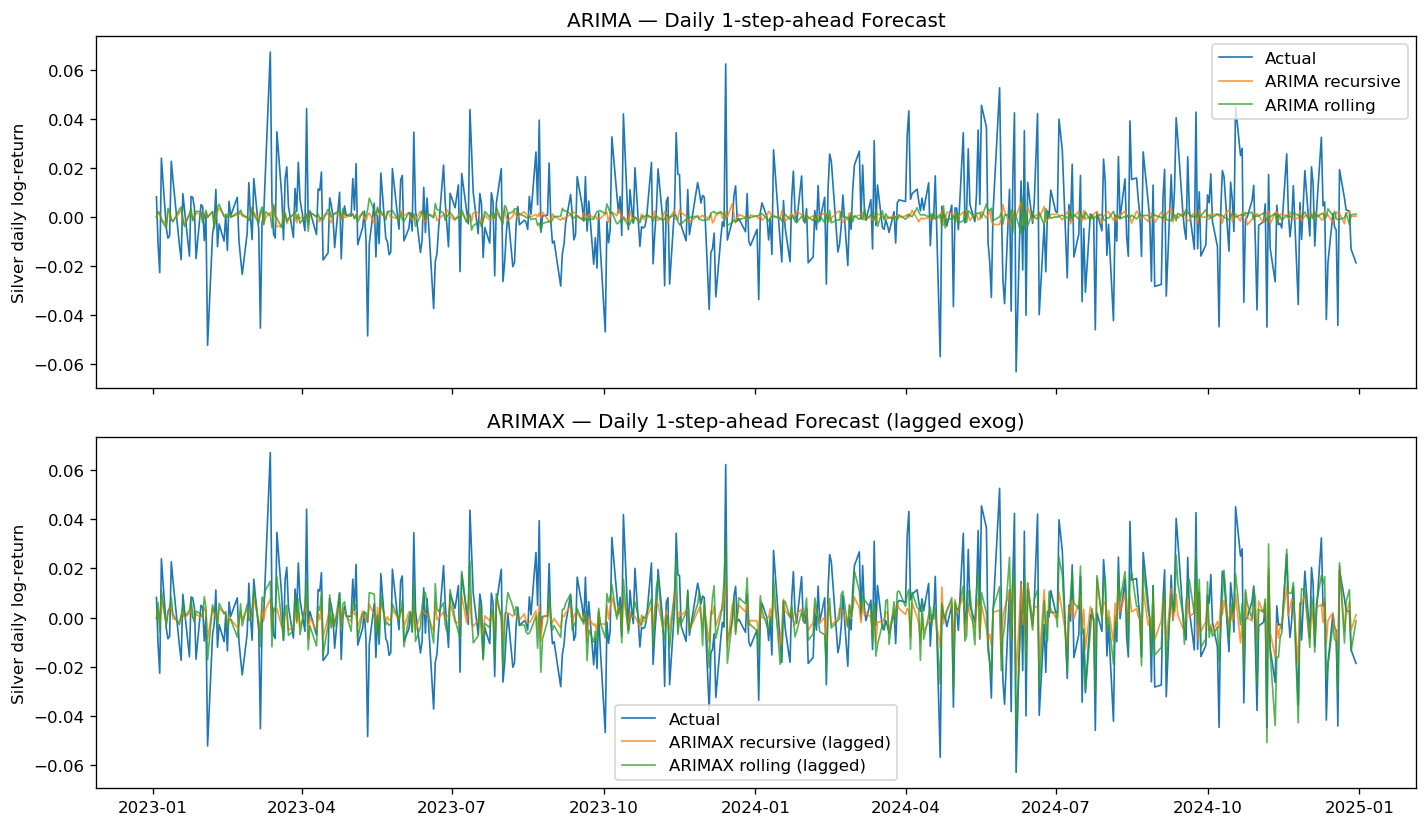

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(y_test.index, actuals,         label='Actual',          lw=1)
axes[0].plot(y_test.index, preds_arima_rec, label='ARIMA recursive', lw=1, alpha=0.8)
axes[0].plot(y_test.index, preds_arima_rol, label='ARIMA rolling',   lw=1, alpha=0.8)
axes[0].set_title('ARIMA — Daily 1-step-ahead Forecast')
axes[0].set_ylabel('Silver daily log-return')
axes[0].legend()

axes[1].plot(y_test.index, actuals,          label='Actual',                   lw=1)
axes[1].plot(y_test.index, preds_arimax_rec, label='ARIMAX recursive (lagged)',lw=1, alpha=0.8)
axes[1].plot(y_test.index, preds_arimax_rol, label='ARIMAX rolling (lagged)',  lw=1, alpha=0.8)
axes[1].set_title('ARIMAX — Daily 1-step-ahead Forecast (lagged exog)')
axes[1].set_ylabel('Silver daily log-return')
axes[1].legend()

plt.tight_layout()
plt.show()
